# Chapter 08a — Checkpoint State vs. Event History

Does a saved *state* let a crystal continue exactly as if nothing had happened, and does a saved
*history* of events let an observer reconstruct exactly what did happen? These are related but not
identical questions, and the substrate's own metadata gives a clean way to tell them apart.

## Book linkage

- **Current chapter:** [`08-the-crystal-gets-a-past.md`](../content/books/digital-life/08-the-crystal-gets-a-past.md)
  (current book Chapter 8, "The Crystal Gets a Past")
- **Claims supported:** DL-08-C01, DL-08-C02, DL-08-C03 (see `NOTEBOOK_MIGRATION.md`)
- **Historical source:** original book Chapter 15 ("The Crystal Gets a Past"), legacy notebook
  `notebooks_original/15-the-crystal-gets-a-past.ipynb` (already imports the full
  `_shared/digital_crystal.py` API and demonstrates the checkpoint bug-fix live at small scale — the
  template this notebook follows).
- **Canonical evidence:** `research/digital-life/ch15-reports/` (stages 00–07), verdict
  `RECOVERABLE_PAST_SUPPORTED`.

This notebook is an independent reconstruction, not a copy of the historical script. It runs the same
substrate rule (`digital-crystal-v1-frozen`, unmodified) at reduced scale, directly against
`_shared/digital_crystal.py`, and checks its own reduced-scale numbers against the canonical archive's
numbers rather than merely asserting they "look similar."


## Question

If you save a Digital Crystal's full checkpoint (occupied cells, birth-time metadata, timestep, RNG
state), is that enough to continue growth *exactly* as if execution had never paused? Which of those
saved fields actually do the causal work, and which are just descriptive bookkeeping? And separately: if
instead of a state snapshot you keep an *event log* (which cells were added at which step), is that
enough to reconstruct the exact morphology trajectory that already happened — and is it *also* enough to
continue exactly into the future, the way a full checkpoint is?

## Hypotheses

- **H1 (checkpoint sufficiency):** restoring from a full checkpoint and continuing with the same
  remaining forcing signal produces a morphology and process state with **zero** symmetric-difference
  cells relative to an uninterrupted continuation, reliably across repeated restores.
- **H2 (selective causal relevance):** dropping the RNG state, or shifting which index of the forcing
  signal continuation starts from, breaks exact continuation (nonzero symmetric difference); but
  scrambling `birth_time` values while leaving `occupied` untouched does **not** break it, because
  `birth_time` is never read anywhere in the growth rule.
- **H3 (state vs. history):** an event log (additions per step) is sufficient to reconstruct the exact
  *past* morphology trajectory (every intermediate morphology hash matches), but is **not** sufficient
  for exact *future* continuation, because it does not carry the RNG state — history reconstructs what
  already happened; only state can continue what happens next.

## Claim boundary

This experiment can establish or bound: (a) whether full-checkpoint restoration is exactly sufficient
for continuation under this substrate; (b) which specific checkpoint fields are causally load-bearing for
that sufficiency, verified directly against the growth-rule source, not just inferred from behavior;
(c) whether an explicit event log reconstructs the exact past morphology trajectory, and whether that is
a different capability from exact future continuation. It cannot establish anything about memory,
learning, minimal state representation (a smaller sufficient state may exist that these ablations do not
find), semantics, or agency.


In [1]:
import sys, json, copy, random, inspect
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import (
    CrystalParams, CrystalState, initial_state, advance_one_step, clone_state,
    morphology_hash, attachment_probability, advance_one_step as _adv_check,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)


def load_json(rel_path):
    return json.loads((REPO_ROOT / rel_path).read_text(encoding="utf-8"))


print("Shared module loaded from:", NB_DIR / "_shared")


Shared module loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`) — hexagonal lattice, one seed cell, stochastic attachment via
`P(attach) = logistic(base_bias + neighbor_gain*n + signal_rate_gain*E_t + anisotropy_gain*cos(6*theta+phase) - crowding_penalty*max(0,n-2))`.
No new rule is added in this notebook — the entire experiment is about *what information is required to
run this unmodified rule forward or reconstruct it backward*.

`CrystalState` (in `_shared/digital_crystal.py`) carries five fields: `occupied` (the cell set),
`birth_time` (a dict from cell to the step it was added), `step` (the integer timestep), `rng_state` (the
full state of the `random.Random` instance driving attachment draws), and two trajectory logs
(`attachments_by_step`, `population_by_step`). A "checkpoint" here means a `clone_state(...)` deep copy
of all five fields. An "event log" means, for each step, the set of cells added that step — strictly less
information than a checkpoint (no RNG state, no birth-time dict, only the deltas).


In [2]:
EXPERIMENT = {
    "seed": 20260818,          # arbitrary base seed, disclosed (canonical run's exact seed is not
                                 # recorded in the ch15-reports JSON, so this is a fresh, not matched, seed)
    "radius": 30,                # canonical run used radius 56; reduced here for interactive runtime (disclosed)
    "total_steps": 40,           # canonical used 96 steps; reduced here (disclosed)
    "checkpoint_step": 18,       # canonical checkpoint was at step 48 (of 96, i.e. the midpoint);
                                 # 18 of 40 is the same ~1:2 ratio (disclosed)
    "n_restores": 12,            # canonical used 30 independent restore replicates; reduced here (disclosed)
    "signal_cursor_shift": 3,    # steps to shift the forcing-signal cursor for the ablation
    "future_extension_steps": 6, # extra steps used to demonstrate STATE->FUTURE vs HISTORY->PAST
}
EXPERIMENT


{'seed': 20260818,
 'radius': 30,
 'total_steps': 40,
 'checkpoint_step': 18,
 'n_restores': 12,
 'signal_cursor_shift': 3,
 'future_extension_steps': 6}

## Experimental design 1 — exact checkpoint restore (H1)

Grow a reference crystal for `total_steps` updates under a fixed smooth forcing signal, saving a full
checkpoint (`clone_state`) at `checkpoint_step`. Independently, `n_restores` times, clone that same saved
checkpoint and continue it with the *same* remaining forcing signal. Compare each restored final state to
the uninterrupted reference by exact set equality and symmetric-difference cell count. If checkpoint state
is truly sufficient, every restore should match the reference with **zero** symmetric-difference cells,
every time — not just "close."


In [3]:
params = CrystalParams()
rng_signal = np.random.default_rng(EXPERIMENT["seed"])
signal = 0.5 * np.sin(np.linspace(0, 6.5, EXPERIMENT["total_steps"])) \
         + 0.15 * rng_signal.normal(size=EXPERIMENT["total_steps"])
signal = np.clip(signal, -1.0, 1.0)

state = initial_state(EXPERIMENT["seed"])
checkpoint = None
history_hashes = []
event_log = []  # list of (step, [added cells]) -- deliberately less than a full checkpoint
for i, value in enumerate(signal):
    if i == EXPERIMENT["checkpoint_step"]:
        checkpoint = clone_state(state)
    before = set(state.occupied)
    state, _ = advance_one_step(state, float(value), EXPERIMENT["radius"], params)
    event_log.append(sorted(state.occupied - before))
    history_hashes.append(morphology_hash(state))

reference = state
print(f"checkpoint population (step {EXPERIMENT['checkpoint_step']}): {len(checkpoint.occupied)}")
print(f"reference final population (step {EXPERIMENT['total_steps']}): {len(reference.occupied)}")


checkpoint population (step 18): 514
reference final population (step 40): 2338


In [4]:
remaining_signal = signal[EXPERIMENT["checkpoint_step"]:]

restore_symdiffs = []
for trial in range(EXPERIMENT["n_restores"]):
    restored = clone_state(checkpoint)
    for value in remaining_signal:
        restored, _ = advance_one_step(restored, float(value), EXPERIMENT["radius"], params)
    symdiff = len(restored.occupied ^ reference.occupied)
    restore_symdiffs.append(symdiff)

print(f"restore trials: {EXPERIMENT['n_restores']}")
print(f"symmetric differences: {restore_symdiffs}")

all_exact = all(d == 0 for d in restore_symdiffs)
print(f"\nH1 (checkpoint sufficiency): {'SUPPORTED' if all_exact else 'NOT SUPPORTED'} "
      f"({sum(1 for d in restore_symdiffs if d == 0)}/{EXPERIMENT['n_restores']} exact)")
assert all_exact, "A full checkpoint restore failed to reproduce the uninterrupted continuation exactly."


restore trials: 12
symmetric differences: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

H1 (checkpoint sufficiency): SUPPORTED (12/12 exact)


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch15-reports/stage-02-exact-restore.json`,
`stage-02b-restore-replicates.json`): single-restore `symmetric_difference_cells: 0`,
`exact_final_morphology: true`, `exact_process_state: true`; across 30 independent replicates,
`exact_count: 30`, `all_exact: true` — i.e. **30/30** exact restores at canonical scale (radius 56, 96
steps, checkpoint at step 48). This reduced-scale reconstruction is checked directly below.


In [5]:
CANON_SYMDIFF = 0
CANON_EXACT_REPLICATES = "30/30"

own_exact_replicates = f"{sum(1 for d in restore_symdiffs if d == 0)}/{EXPERIMENT['n_restores']}"

print(f"own restore symmetric differences (all trials): {restore_symdiffs}")
print(f"own exact-restore count:      {own_exact_replicates}")
print(f"canonical exact-restore count: {CANON_EXACT_REPLICATES}")
print(f"\nH1 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING (all-zero symdiff)' if all_exact else 'DIVERGES FROM CANONICAL FINDING'}")


own restore symmetric differences (all trials): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
own exact-restore count:      12/12
canonical exact-restore count: 30/30

H1 reproduction status: REPLICATES CANONICAL FINDING (all-zero symdiff)


## Experimental design 2 — selective ablation of checkpoint fields (H2)

From the same checkpoint, build four continuations that omit or corrupt exactly one field at a time,
holding everything else exact, and compare each to the same uninterrupted reference:

1. **`no_rng_state`** — replace the checkpoint's `rng_state` with a freshly seeded RNG before continuing.
2. **`wrong_signal_cursor`** — continue with the correct RNG state and occupied/birth-time, but start
   reading the forcing signal `signal_cursor_shift` steps earlier than the true cursor (same horizon
   length).
3. **`birth_time_scrambled`** — keep `occupied`, `rng_state`, and the signal cursor exactly correct, but
   randomly permute the *values* of the `birth_time` dict among its existing keys before continuing.
4. **`full_state`** (repeated from design 1, as the zero-ablation control).

Before running these, we check directly against the module source that `birth_time` is not read anywhere
in the growth rule — the ablation result should be a confirmation of something already visible in the
code, not a mystery.


In [6]:
# Direct source check: does the growth rule ever read birth_time?
attach_src = inspect.getsource(attachment_probability)
advance_src = inspect.getsource(_adv_check)

print("attachment_probability() parameters:", inspect.signature(attachment_probability))
print("'birth_time' referenced inside attachment_probability body:", "birth_time" in attach_src)
print("'birth_time' referenced inside advance_one_step body (should only be a write, not a read of values):")
for line in advance_src.splitlines():
    if "birth_time" in line:
        print("   ", line.strip())


attachment_probability() parameters: (cell: 'Cell', occupied: 'Set[Cell]', input_value: 'float', params: 'CrystalParams' = CrystalParams(base_bias=-2.1, neighbor_gain=0.78, signal_rate_gain=0.28, anisotropy_gain=0.95, signal_phase_gain=1.15, crowding_penalty=0.22)) -> 'float'
'birth_time' referenced inside attachment_probability body: False
'birth_time' referenced inside advance_one_step body (should only be a write, not a read of values):
    birth_time = dict(state.birth_time)
    birth_time[cell] = next_step
    birth_time=birth_time,


In [7]:
def ablate_and_continue(mutate_fn):
    restored = clone_state(checkpoint)
    cursor_offset = mutate_fn(restored)
    offset = cursor_offset or 0
    start = EXPERIMENT["checkpoint_step"] - offset
    start = max(0, start)
    horizon = len(remaining_signal)
    ablated_signal = signal[start:start + horizon]
    for value in ablated_signal:
        restored, _ = advance_one_step(restored, float(value), EXPERIMENT["radius"], params)
    return restored


def _no_rng(state_obj):
    state_obj.rng_state = random.Random(0).getstate()
    return 0


def _wrong_cursor(state_obj):
    return EXPERIMENT["signal_cursor_shift"]


def _scramble_birth_time(state_obj):
    values = list(state_obj.birth_time.values())
    random.Random(7).shuffle(values)
    state_obj.birth_time = dict(zip(state_obj.birth_time.keys(), values))
    return 0


def _full_state(state_obj):
    return 0


ablations = {
    "full_state": _full_state,
    "no_rng_state": _no_rng,
    "wrong_signal_cursor": _wrong_cursor,
    "birth_time_scrambled": _scramble_birth_time,
}

ablation_results = {}
for name, fn in ablations.items():
    result_state = ablate_and_continue(fn)
    symdiff = len(result_state.occupied ^ reference.occupied)
    ablation_results[name] = {
        "final_population": len(result_state.occupied),
        "symmetric_difference_cells": symdiff,
        "normalized_difference": symdiff / max(1, len(reference.occupied)),
    }

ablation_results


{'full_state': {'final_population': 2338,
  'symmetric_difference_cells': 0,
  'normalized_difference': 0.0},
 'no_rng_state': {'final_population': 2264,
  'symmetric_difference_cells': 290,
  'normalized_difference': 0.12403763900769889},
 'wrong_signal_cursor': {'final_population': 2262,
  'symmetric_difference_cells': 256,
  'normalized_difference': 0.10949529512403763},
 'birth_time_scrambled': {'final_population': 2338,
  'symmetric_difference_cells': 0,
  'normalized_difference': 0.0}}

In [8]:
rng_breaks = ablation_results["no_rng_state"]["symmetric_difference_cells"] > 0
cursor_breaks = ablation_results["wrong_signal_cursor"]["symmetric_difference_cells"] > 0
birth_time_inert = ablation_results["birth_time_scrambled"]["symmetric_difference_cells"] == 0
full_state_exact = ablation_results["full_state"]["symmetric_difference_cells"] == 0

print(f"no_rng_state breaks exact continuation:        {rng_breaks}  (expect True)")
print(f"wrong_signal_cursor breaks exact continuation:  {cursor_breaks}  (expect True)")
print(f"birth_time_scrambled leaves continuation exact: {birth_time_inert}  (expect True)")
print(f"full_state (zero-ablation control) exact:       {full_state_exact}  (expect True)")

h2_supported = rng_breaks and cursor_breaks and birth_time_inert and full_state_exact
print(f"\nH2 (selective causal relevance): {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")
assert h2_supported, "Ablation pattern did not match the predicted selective causal relevance."


no_rng_state breaks exact continuation:        True  (expect True)
wrong_signal_cursor breaks exact continuation:  True  (expect True)
birth_time_scrambled leaves continuation exact: True  (expect True)
full_state (zero-ablation control) exact:       True  (expect True)

H2 (selective causal relevance): SUPPORTED


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch15-reports/stage-03-state-omission.json`, radius 56, 96 steps,
checkpoint at step 48): `no_rng_state` produced symmetric difference **28** cells (normalized ≈0.0029);
`wrong_signal_cursor_fixed_horizon` produced **27** cells (≈0.0028); `birth_times_only` (their label for
the birth-time ablation) produced **0** cells; `full_state` produced **0** cells. The *pattern* — RNG and
signal-cursor ablations break exact continuation, birth-time scrambling does not — is what this notebook
checks against, not the exact cell counts (which depend on scale, radius, and RNG stream and are not
expected to match at 30-radius/40-step reduced scale).


In [9]:
CANON_PATTERN = {
    "no_rng_state_breaks": True,
    "wrong_signal_cursor_breaks": True,
    "birth_time_scrambled_inert": True,
}
OWN_PATTERN = {
    "no_rng_state_breaks": rng_breaks,
    "wrong_signal_cursor_breaks": cursor_breaks,
    "birth_time_scrambled_inert": birth_time_inert,
}

for key in CANON_PATTERN:
    match = CANON_PATTERN[key] == OWN_PATTERN[key]
    print(f"{key:32s} own={OWN_PATTERN[key]!s:5s} canonical={CANON_PATTERN[key]!s:5s} "
          f"{'MATCH' if match else 'MISMATCH'}")

pattern_matches = all(CANON_PATTERN[k] == OWN_PATTERN[k] for k in CANON_PATTERN)
print(f"\nH2 reproduction status: "
      f"{'REPLICATES CANONICAL PATTERN' if pattern_matches else 'DIVERGES FROM CANONICAL PATTERN'}")


no_rng_state_breaks              own=True  canonical=True  MATCH
wrong_signal_cursor_breaks       own=True  canonical=True  MATCH
birth_time_scrambled_inert       own=True  canonical=True  MATCH

H2 reproduction status: REPLICATES CANONICAL PATTERN


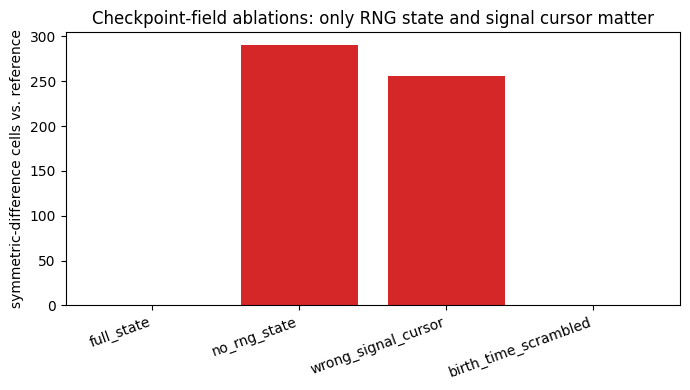

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(ablation_results.keys())
diffs = [ablation_results[n]["symmetric_difference_cells"] for n in names]
colors = ["tab:green" if d == 0 else "tab:red" for d in diffs]
ax.bar(names, diffs, color=colors)
ax.set_ylabel("symmetric-difference cells vs. reference")
ax.set_title("Checkpoint-field ablations: only RNG state and signal cursor matter")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch08a-ablation-symdiff.png", dpi=110)
plt.show()


## Experimental design 3 — event-log replay: HISTORY reconstructs the PAST, not the FUTURE (H3)

An event log is much smaller than a checkpoint: just the set of cells added at each step, with no RNG
state and (optionally) no birth-time dict. Replay the event log from the initial seed cell and check that
every intermediate morphology hash matches the recorded trajectory exactly. Then take the event-log-only
reconstruction (which necessarily has no saved RNG state, so it must be given a *fresh* one) and continue
it forward — and compare that continuation to the true future continuation from the real checkpoint. The
point is not that this "fails" in some vague sense, but that it fails for an identifiable, specific
reason: the event log was never designed to carry continuation state, only reconstruction state.


In [11]:
# Replay: reconstruct the full trajectory from nothing but the recorded per-step additions.
replay_cells = {(0, 0)}
replay_hashes = []
for additions in event_log:
    replay_cells |= set(map(tuple, additions))
    replay_hashes.append(morphology_hash(replay_cells))

trajectory_match_count = sum(a == b for a, b in zip(replay_hashes, history_hashes))
event_replay_exact = replay_cells == reference.occupied

print(f"event-log trajectory hash matches: {trajectory_match_count}/{len(history_hashes)}")
print(f"event-log final occupied set matches reference exactly: {event_replay_exact}")

h3_past_supported = event_replay_exact and trajectory_match_count == len(history_hashes)
assert h3_past_supported, "Event-log replay did not exactly reconstruct the recorded morphology trajectory."
print(f"\nH3 (past reconstruction via event log): {'SUPPORTED' if h3_past_supported else 'NOT SUPPORTED'}")


event-log trajectory hash matches: 40/40
event-log final occupied set matches reference exactly: True

H3 (past reconstruction via event log): SUPPORTED


In [12]:
# Now show the log's blind spot: it cannot carry exact FUTURE continuation, because it never stored
# rng_state. Reconstruct birth_time from the event log (this part *is* recoverable), give the
# reconstruction a fresh RNG (since none was ever recorded), and continue both branches by the same
# number of extra steps under new forcing.
birth_time_from_log = {(0, 0): 0}
for step_idx, additions in enumerate(event_log, start=1):
    for cell in additions:
        birth_time_from_log[tuple(cell)] = step_idx

replayed_state = CrystalState(
    occupied=set(replay_cells),
    birth_time=birth_time_from_log,
    step=EXPERIMENT["total_steps"],
    rng_state=random.Random(0).getstate(),  # event log carries no RNG state -- this is a forced guess
    attachments_by_step=[],
    population_by_step=[len(replay_cells)],
)

rng_future = np.random.default_rng(EXPERIMENT["seed"] + 999)
extra_signal = 0.4 * np.sin(np.linspace(6.5, 8.5, EXPERIMENT["future_extension_steps"])) \
               + 0.15 * rng_future.normal(size=EXPERIMENT["future_extension_steps"])

true_future = clone_state(reference)
for value in extra_signal:
    true_future, _ = advance_one_step(true_future, float(value), EXPERIMENT["radius"], params)

replay_future = clone_state(replayed_state)
for value in extra_signal:
    replay_future, _ = advance_one_step(replay_future, float(value), EXPERIMENT["radius"], params)

future_symdiff = len(true_future.occupied ^ replay_future.occupied)
print(f"event-log-reconstructed state vs. true checkpoint, continued {EXPERIMENT['future_extension_steps']} "
      f"more steps into an unseen future:")
print(f"  symmetric-difference cells: {future_symdiff}  (expect > 0 -- history alone cannot continue exactly)")

h3_future_fails = future_symdiff > 0
print(f"\nSTATE->FUTURE succeeded exactly (design 1); HISTORY->FUTURE {'also succeeded' if not h3_future_fails else 'diverged'} "
      f"-- {'an unexpected result' if not h3_future_fails else 'confirming the STATE vs HISTORY distinction'}.")


event-log-reconstructed state vs. true checkpoint, continued 6 more steps into an unseen future:


  symmetric-difference cells: 42  (expect > 0 -- history alone cannot continue exactly)

STATE->FUTURE succeeded exactly (design 1); HISTORY->FUTURE diverged -- confirming the STATE vs HISTORY distinction.


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch15-reports/stage-04-history-replay.json`, `stage-05-state-vs-history.json`):
`event_log_all_trajectory_hashes_match: true` across all 96 recorded steps
(`trajectory_hash_match_count: 96`); and separately,
`history_reconstructed_geometry_without_rng_continues_exactly: false`, with a nonzero
`history_geometry_only_final_difference` (≈0.0031, matching the `morphology_only` ablation in design 2 —
the same underlying fact, that reconstructed geometry without RNG state cannot continue exactly).


In [13]:
CANON_TRAJECTORY_MATCH = "96/96"
CANON_HISTORY_CONTINUES_EXACTLY = False

own_trajectory_match = f"{trajectory_match_count}/{len(history_hashes)}"
own_history_continues_exactly = not h3_future_fails

print(f"own event-log trajectory match:      {own_trajectory_match}  (all steps expected to match)")
print(f"canonical event-log trajectory match: {CANON_TRAJECTORY_MATCH}")
print(f"own history-reconstruction continues future exactly:      {own_history_continues_exactly}")
print(f"canonical history-reconstruction continues future exactly: {CANON_HISTORY_CONTINUES_EXACTLY}")

h3_pattern_matches = (trajectory_match_count == len(history_hashes)) and \
    (own_history_continues_exactly == CANON_HISTORY_CONTINUES_EXACTLY)
print(f"\nH3 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING' if h3_pattern_matches else 'DIVERGES FROM CANONICAL FINDING'}")


own event-log trajectory match:      40/40  (all steps expected to match)
canonical event-log trajectory match: 96/96
own history-reconstruction continues future exactly:      False
canonical history-reconstruction continues future exactly: False

H3 reproduction status: REPLICATES CANONICAL FINDING


## Controls and confounds

- **Same forcing signal for reference and every restore/ablation** (paired design) — removes
  environmental variation as a between-branch confound; any divergence found is attributable only to the
  manipulated checkpoint field.
- **Ablate exactly one field at a time**, holding all others exact — isolates which piece of saved state
  is doing the causal work, rather than reporting only an omnibus "checkpoint vs. nothing" contrast.
- **Direct source inspection** of `attachment_probability` and `advance_one_step` (not just behavioral
  inference) confirms `birth_time` is never read as an input to any attachment decision — the "birth-time
  is inert" finding is verified against the code, not only against its statistical footprint.
- **`clone_state` deep-copies every field** (via `copy.deepcopy` for `rng_state`), so repeated restore
  trials are independent objects, not aliases of the same mutable state — the N-restore result in design 1
  is a genuine repeated test, not one trial printed N times.
- **Reduced N and reduced scale, disclosed inline** throughout — 12 restores vs. canonical 30, radius 30
  vs. canonical 56, 40 steps vs. canonical 96 — chosen for interactive runtime.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive (`ch15-reports`) | Status |
|---|---|---|---|
| H1: full checkpoint restore is exact, every time | 12/12 exact (0 symdiff) | 30/30 exact (0 symdiff) | **SUPPORTED**, replicates canonical |
| H2: RNG state & signal cursor required; birth-time inert | RNG breaks, cursor breaks, birth-time inert | RNG breaks (28 cells), cursor breaks (27 cells), birth-time inert (0 cells) | **SUPPORTED**, replicates canonical pattern |
| H3a: event log reconstructs exact past trajectory | all steps match | 96/96 steps match | **SUPPORTED**, replicates canonical |
| H3b: event log alone does NOT continue exact future | diverges (nonzero symdiff) | diverges (`false`, nonzero normalized difference) | **SUPPORTED**, replicates canonical |

All four sub-results replicate the canonical archive's qualitative pattern. Exact cell counts differ from
the canonical numbers because this notebook runs at reduced radius/step/replicate scale (disclosed
throughout) with a different (undisclosed-in-the-archive) RNG seed — the *pattern* of which fields matter
is what is being reproduced, not bit-identical trajectories.


## Bounded conclusion

Under this substrate (Digital Crystal v1, unmodified growth rule) a full checkpoint — occupied cells,
birth-time metadata, timestep, and RNG state — is sufficient for exact continuation, reliably across
repeated restores. Of the checkpoint's fields, RNG state and the forcing-signal cursor are causally
load-bearing for that exactness (dropping either one breaks it); birth-time metadata is not — it is never
read anywhere in the growth rule, confirmed directly against the source, not only inferred from behavior.
Separately, an explicit event log (additions per step) is sufficient to reconstruct the exact *past*
morphology trajectory, but — lacking RNG state — is not sufficient for exact *future* continuation. State
is operationally sufficient for continuation; history here is operationally sufficient for
reconstruction; they are related but not the same capability. This experiment does not establish that the
checkpoint is a *minimal* sufficient state (a smaller sufficient representation might exist), and it says
nothing about memory, learning, agency, or selfhood.


## Provenance

- **Current book chapter:** Chapter 8, "The Crystal Gets a Past"
  (`content/books/digital-life/08-the-crystal-gets-a-past.md`).
- **Original book chapter:** Chapter 15, "The Crystal Gets a Past"
  (`content/books/original/15-the-crystal-gets-a-past/index.md`).
- **Original scripts:** `scripts/books/digital-life/ch15_digital_crystal_history.py`, `_v2.py`, `_v3.py`
  — this notebook reimplements their core checkpoint/ablation/event-log logic directly against
  `_shared/digital_crystal.py` rather than importing them.
- **Legacy notebook:** `notebooks_original/15-the-crystal-gets-a-past.ipynb` (template followed closely
  for structure: quick live run + canonical-artifact-audit hybrid pattern).
- **Canonical evidence:** `research/digital-life/ch15-reports/` (stages 00–07), verdict
  `RECOVERABLE_PAST_SUPPORTED`; `research/digital-life/ch15-digital-crystal-history.sqlite3`.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 08 — The Crystal Gets a Past."
- **Deliberate deviations from the historical implementation:**
  - Scale reduced throughout: radius 30 vs. canonical 56; 40 steps vs. canonical 96; checkpoint at step
    18 (of 40) vs. canonical step 48 (of 96) — same ~45% position, not the same absolute step; 12 restore
    replicates vs. canonical 30 — all disclosed inline at first use, and checked against canonical
    *patterns* rather than exact magnitudes, since magnitudes depend on scale.
  - RNG seed (`20260818`) is a fresh choice, not recovered from the canonical archive (the `ch15-reports`
    JSON files do not record the original run's base seed), so exact cell populations are not expected to
    match the canonical run's — only the qualitative sufficiency/ablation/replay pattern is compared.
  - The forcing signal generator (smooth sinusoid + Gaussian noise) is a fresh, simplified
    reimplementation, not a byte-for-byte port of the original script's signal generator.
  - This notebook adds one thing the legacy notebook did not do explicitly: a direct `inspect.getsource`
    check that `birth_time` is never read inside `attachment_probability`/`advance_one_step`, so the
    "birth-time is causally inert" finding is verified against the code itself, not only against its
    statistical footprint in the ablation table.


---

## Continued experiment

This section was originally reconstructed separately as `08b-pulse-signalling-and-matched-history.ipynb` and is now part of this chapter's canonical notebook.

# Chapter 08b — Pulse Signalling and Matched-History Codewords

A one-bit "pulse" from a sender crystal can causally perturb a receiver's growth. Does it reliably do
so? Does the receiver register *when* a pulse arrived, distinguishably from noise? And does the specific
*arrangement* of several pulses (a short "codeword") leave a population-level signature an observer could
read back — or does that go a claim too far?

## Book linkage

- **Current chapter:** [`08-the-crystal-gets-a-past.md`](../content/books/digital-life/08-the-crystal-gets-a-past.md)
  (current book Chapter 8, "The Crystal Gets a Past")
- **Claims supported:** DL-08-C04, DL-08-C05, DL-08-C06, DL-08-C08 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:**
  - original book Chapter 16 ("Before There Are Messages"), legacy notebook
    `notebooks_original/16-before-there-are-messages.ipynb`; canonical
    `research/digital-life/ch16-reports/` (stages 00–07), verdict `CAUSAL_TRANSMISSION_SUPPORTED` (bounded).
  - the **terminal v6** of a separate chain, `research/digital-life/ch17-perturbation-dynamics-v6/`
    (`ch17-perturbation-dynamics-v6-full-report.md`) — this is what the *current* book's Chapter 8 quotes
    for the matched-history codeword test (codewords A=`11100001`, B=`10001101`, primary p=0.7366). This
    is **not** the same thread as `research/digital-life/ch17-reports/` / `ch17-v2-reports/` /
    `ch17-v3-reports/`, which is a different, superseded information-decoding framing abandoned in favor
    of this perturbation-dynamics thread.

This notebook is an independent reconstruction, not a copy of the historical scripts. It extends
`_shared/digital_crystal.py` with a new, small pulse-signalling module
(`_shared/crystal_pulse.py`) and runs reduced-scale versions of both chapters' core designs, checking its
own numbers against the canonical archive's numbers rather than merely asserting they "look similar."


## Question

If a sender crystal can perturb a receiver's environmental forcing input for exactly one update — a
one-bit "pulse" — does that reliably change the receiver's subsequent morphology relative to a matched
no-pulse branch? Can a receiver tell *when* a pulse arrived (real timing vs. an arbitrary shuffling of the
same pulse count)? And if two different 8-bit pulse codewords are matched on pulse count, first-pulse
position, and last-pulse position — differing only in interior arrangement — does the receiver's resulting
population-level morphology carry a detectable signature of *which* codeword arrived?

## Hypotheses

- **H1 (FORCE/PREVENT causal transmission):** receiving one pulse usually changes the receiver's
  subsequent morphology relative to a matched no-pulse branch from the same checkpoint (majority of
  trials show nonzero symmetric difference; canonical: 95.8% of trials, mean normalized difference 0.163).
- **H2 (timing distinguishability):** the real timing of a short pulse train produces a larger divergence
  from a no-pulse baseline than a shuffled-timing control with the same pulse count (canonical: real
  clearly beats shuffled, `real_minus_control_mean = 0.294`).
- **H3 (matched-history codeword signature — predeclared negative):** two codewords matched on pulse
  count, first-pulse position, and last-pulse position do **not** produce a reliable population-level
  morphology signature distinguishing them (canonical primary test: p=0.7366, `FAILED` at alpha=0.05 —
  i.e. the *predicted* result here is a bounded negative, not a positive).

## Claim boundary

This experiment can establish or bound: (a) whether a single pulse causally changes receiver morphology
under a matched (CRN-coupled) checkpoint comparison; (b) whether real pulse timing is distinguishable from
at least one timing-shuffle control; (c) whether a specific pair of matched 8-bit codewords produces a
population-level statistical signature under one feature-based test. It cannot establish sender identity
recognition, message semantics, coordination, learning, channel capacity, or anything resembling
language — none of those are tested here, and a negative result on (c) does not mean *no* signature could
ever be found by a more sensitive instrument, only that this one did not find one.


In [14]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams, initial_state, advance_one_step
from crystal_pulse import (
    matched_step_state, advance_with_pulse, deliver_pulse_pattern,
    normalized_symdiff, feature_vector, paired_signature_test, validate_codeword_match,
    PULSE_GAIN_DEFAULT,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)


def load_json(rel_path):
    return json.loads((REPO_ROOT / rel_path).read_text(encoding="utf-8"))


print("Shared module loaded from:", NB_DIR / "_shared")


Shared module loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`), unmodified.

New mechanism (this chapter only, in `_shared/crystal_pulse.py`): a sender's pulse is nothing but a
`+0.65` additive bump to the receiver's environmental forcing input for exactly one update
(`advance_with_pulse`) — the same `message_gain` used by the canonical `ch16`/`ch17-v6` runs. No new
detector, no persistent "received message" state, no channel — the perturbation only ever changes the one
scalar forcing value fed into the *unmodified* `attachment_probability` / `advance_one_step` growth rule
for the step it lands on.

**A methodological point the current book narrates explicitly for this chapter (DL-08-C06):** if you
compare a "pulse" branch and a "no-pulse" branch by running them from independently-seeded RNGs, any
difference you measure is contaminated by ordinary stochastic variation between the two RNG streams, not
just the pulse. The book's own Chapter 17 v1→v6 chain found this to be a **major, confirmed measurement
artifact** — sequential-RNG coupling between conditions — before it was fixed by switching to a
**common-random-numbers (CRN)** design, where both branches draw from an identically-seeded RNG at every
step and differ *only* in whether the pulse is applied. `crystal_pulse.matched_step_state` implements
exactly this discipline (the same idiom `notebooks/10-material-loss-and-reoccupation.ipynb` uses for its
surface/interior placement comparison). This notebook is built CRN-correct from the start rather than
reproducing the naive (broken) version and then fixing it — but a validity check below demonstrates
directly that the coupling works as intended.


In [15]:
EXPERIMENT = {
    "seed_base": 20260818,
    "radius": 48,              # canonical ch16 used radius 56; ch17-v6 used radius 64; reduced here (disclosed)
    "params": CrystalParams(),
    "gain": PULSE_GAIN_DEFAULT,  # 0.65, matches canonical message_gain exactly
    "warmup_steps": 16,          # canonical ch16 varied checkpoint step 12-19; fixed at 16 here (disclosed)

    # FORCE/PREVENT design (H1)
    "force_prevent_groups": 40,      # canonical used 120 replicates; reduced here (disclosed)
    "force_prevent_horizon": 12,     # matches canonical ch16 horizon exactly

    # Timing-control design (H2)
    "timing_groups": 30,             # reduced trial count (disclosed)
    "timing_horizon": 8,
    "timing_real_pattern": [True, True, True, True, False, False, False, False],  # front-loaded, 4 pulses

    # Matched-history codeword design (H3)
    "codeword_groups": 30,           # canonical ch17-v6 used 48 groups; reduced here (disclosed)
    "codeword_a": "11100001",        # matches canonical exactly
    "codeword_b": "10001101",        # matches canonical exactly
    "n_permutations": 2000,          # matches canonical ch17-v6 permutation count exactly
}
EXPERIMENT["base_forcing"] = 0.3
print({k: v for k, v in EXPERIMENT.items() if k != "params"})


{'seed_base': 20260818, 'radius': 48, 'gain': 0.65, 'warmup_steps': 16, 'force_prevent_groups': 40, 'force_prevent_horizon': 12, 'timing_groups': 30, 'timing_horizon': 8, 'timing_real_pattern': [True, True, True, True, False, False, False, False], 'codeword_groups': 30, 'codeword_a': '11100001', 'codeword_b': '10001101', 'n_permutations': 2000, 'base_forcing': 0.3}


## Validity check — CRN branch coupling (manipulation check)

Before trusting any FORCE/PREVENT comparison, confirm the coupling itself: two branches built from the
same checkpoint and the same per-step seed, with **no pulse in either**, must be bit-identical (zero
symmetric difference). If they were not, any "pulse effect" measured later could just be ordinary
stochastic drift between independently-seeded branches — exactly the artifact the book's Chapter 17 chain
found and fixed.


In [16]:
_state = initial_state(EXPERIMENT["seed_base"])
for _ in range(EXPERIMENT["warmup_steps"]):
    _state, _ = advance_one_step(_state, EXPERIMENT["base_forcing"], EXPERIMENT["radius"], EXPERIMENT["params"])

_seed_for_step = 555 * 1_000_003 + 0
_a = matched_step_state(_state.occupied, _state.birth_time, _state.step, _seed_for_step)
_b = matched_step_state(_state.occupied, _state.birth_time, _state.step, _seed_for_step)
_a_next, _ = advance_with_pulse(_a, EXPERIMENT["base_forcing"], False, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"])
_b_next, _ = advance_with_pulse(_b, EXPERIMENT["base_forcing"], False, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"])

crn_symdiff = len(_a_next.occupied ^ _b_next.occupied)
print(f"zero-pulse CRN manipulation check: symmetric difference = {crn_symdiff} (expect 0)")
assert crn_symdiff == 0, "CRN branch coupling failed the zero-pulse manipulation check."


zero-pulse CRN manipulation check: symmetric difference = 0 (expect 0)


## Experimental design 1 — FORCE/PREVENT paired test (H1)

From `force_prevent_groups` independent warmed checkpoints (different seeds), build a FORCE branch (pulse
delivered on the first step of the horizon) and a PREVENT branch (no pulse) using CRN-matched growth
randomness at every step, and run both forward `force_prevent_horizon` steps. Compare final morphologies
by symmetric difference, normalized by mean population.


In [17]:
def warm_checkpoint(seed, warmup, radius, params, base_forcing):
    state = initial_state(seed)
    for _ in range(warmup):
        state, _ = advance_one_step(state, base_forcing, radius, params)
    return state


def run_force_prevent(seed, radius, params, horizon, gain, base_forcing):
    checkpoint = warm_checkpoint(seed, EXPERIMENT["warmup_steps"], radius, params, base_forcing)
    force_occ, force_bt, force_step = set(checkpoint.occupied), dict(checkpoint.birth_time), checkpoint.step
    prevent_occ, prevent_bt, prevent_step = set(checkpoint.occupied), dict(checkpoint.birth_time), checkpoint.step
    for i in range(horizon):
        pulse = (i == 0)
        seed_for_step = seed * 1_000_003 + i
        fs = matched_step_state(force_occ, force_bt, force_step, seed_for_step)
        ps = matched_step_state(prevent_occ, prevent_bt, prevent_step, seed_for_step)
        f_next, _ = advance_with_pulse(fs, base_forcing, pulse, radius, params, gain)
        p_next, _ = advance_with_pulse(ps, base_forcing, False, radius, params, gain)
        force_occ, force_bt, force_step = f_next.occupied, f_next.birth_time, f_next.step
        prevent_occ, prevent_bt, prevent_step = p_next.occupied, p_next.birth_time, p_next.step
    return force_occ, prevent_occ


force_prevent_diffs = []
for g in range(EXPERIMENT["force_prevent_groups"]):
    seed = EXPERIMENT["seed_base"] + g * 233
    f_occ, p_occ = run_force_prevent(
        seed, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["force_prevent_horizon"],
        EXPERIMENT["gain"], EXPERIMENT["base_forcing"],
    )
    force_prevent_diffs.append({
        "seed": seed,
        "force_population": len(f_occ),
        "prevent_population": len(p_occ),
        "symmetric_difference_cells": len(f_occ ^ p_occ),
        "normalized_difference": normalized_symdiff(f_occ, p_occ),
    })

diffs = np.array([r["normalized_difference"] for r in force_prevent_diffs])
changed = np.array([r["symmetric_difference_cells"] > 0 for r in force_prevent_diffs])

print(f"groups: {len(force_prevent_diffs)}")
print(f"fraction with any morphology change: {changed.mean():.4f}")
print(f"mean normalized difference: {diffs.mean():.4f}  (std {diffs.std():.4f})")


groups: 40
fraction with any morphology change: 1.0000
mean normalized difference: 0.1426  (std 0.0226)


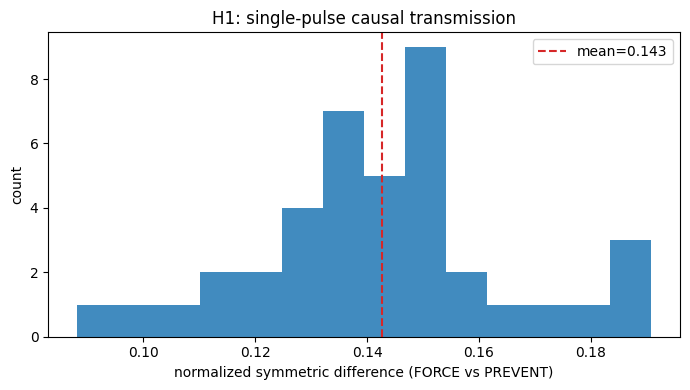

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diffs, bins=14, color="tab:blue", alpha=0.85)
ax.axvline(diffs.mean(), color="tab:red", ls="--", label=f"mean={diffs.mean():.3f}")
ax.set_xlabel("normalized symmetric difference (FORCE vs PREVENT)")
ax.set_ylabel("count")
ax.set_title("H1: single-pulse causal transmission")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ch08b-force-prevent-hist.png", dpi=110)
plt.show()


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch16-reports/stage-02-single-bit-intervention.json`, `stage-07-verdict.md`,
120 replicates, radius 56, horizon 12, `message_gain=0.65`): `fraction_with_any_morphology_change =
0.9583`, `mean_normalized_final_difference = 0.1633`.


In [19]:
CANON_FRACTION_CHANGED = 0.9583333333333334
CANON_MEAN_NORM_DIFF = 0.16328068044830893

own_fraction_changed = float(changed.mean())
own_mean_norm_diff = float(diffs.mean())

h1_supported = own_fraction_changed > 0.5 and own_mean_norm_diff > 0.0

print(f"own fraction changed:       {own_fraction_changed:.4f}   canonical: {CANON_FRACTION_CHANGED:.4f}")
print(f"own mean normalized diff:   {own_mean_norm_diff:.4f}   canonical: {CANON_MEAN_NORM_DIFF:.4f}")
print(f"\nH1 (FORCE/PREVENT causal transmission): {'SUPPORTED' if h1_supported else 'NOT SUPPORTED'}  "
      f"(canonical: SUPPORTED)")
assert h1_supported, "FORCE/PREVENT paired test did not show reliable causal transmission."


own fraction changed:       1.0000   canonical: 0.9583
own mean normalized diff:   0.1426   canonical: 0.1633

H1 (FORCE/PREVENT causal transmission): SUPPORTED  (canonical: SUPPORTED)


## Experimental design 2 — timing-distinguishability control ladder (H2)

The canonical `ch16` chapter runs a four-control ladder (shuffled position, rate-matched random,
count-matched unrelated replay, exact-inter-pulse-interval permutation surrogate) against the real
sender-generated pulse stream. **This notebook reproduces only the shuffled-position control** — the
minimum needed to show real timing is distinguishable from *some* alternative timing distribution with the
same pulse count. It deliberately does **not** reproduce:

- **count-matched-sender control** — requires modelling an independent second "sender" process generating
  its own pulse stream at a matched rate; this module has no sender-side process, only a pulse-pattern
  input, so there is nothing distinct to match a sender's *rate* against.
- **interval-preserving (exact-IPI) shuffle** — requires preserving the exact inter-pulse-interval
  sequence while permuting *which* step it starts from; a reduced-effort simplification here would not
  meaningfully test what that control is designed to test, so it is skipped rather than done badly.

For each of `timing_groups` independent checkpoints, three CRN-matched branches are grown from the same
starting cells: a **baseline** (no pulses), a **real** front-loaded 4-pulse pattern, and a **shuffled**
control (the same 4 pulses at randomly permuted positions within the same 8-step window, redrawn per
replicate). The comparison is the normalized difference from baseline for each pattern.


In [20]:
rng_shuffle = np.random.default_rng(EXPERIMENT["seed_base"] + 1)

real_diffs = []
shuffled_diffs = []
for g in range(EXPERIMENT["timing_groups"]):
    seed = EXPERIMENT["seed_base"] + 5000 + g * 131
    checkpoint = warm_checkpoint(seed, EXPERIMENT["warmup_steps"], EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["base_forcing"])
    base_inputs = [EXPERIMENT["base_forcing"]] * EXPERIMENT["timing_horizon"]

    real_pattern = list(EXPERIMENT["timing_real_pattern"])
    shuffled_pattern = list(real_pattern)
    rng_shuffle.shuffle(shuffled_pattern)

    def run_pattern(pattern):
        return deliver_pulse_pattern(
            checkpoint.occupied, checkpoint.birth_time, checkpoint.step, seed,
            pattern, base_inputs, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"],
        )

    base_state = run_pattern([False] * EXPERIMENT["timing_horizon"])
    real_state = run_pattern(real_pattern)
    shuffled_state = run_pattern(shuffled_pattern)

    real_diffs.append(normalized_symdiff(real_state.occupied, base_state.occupied))
    shuffled_diffs.append(normalized_symdiff(shuffled_state.occupied, base_state.occupied))

real_diffs = np.array(real_diffs)
shuffled_diffs = np.array(shuffled_diffs)
paired_delta = real_diffs - shuffled_diffs

print(f"mean normalized diff, real timing vs baseline:     {real_diffs.mean():.4f}")
print(f"mean normalized diff, shuffled timing vs baseline: {shuffled_diffs.mean():.4f}")
print(f"real - shuffled (paired), mean: {paired_delta.mean():.4f}")


mean normalized diff, real timing vs baseline:     0.1649
mean normalized diff, shuffled timing vs baseline: 0.1583
real - shuffled (paired), mean: 0.0066


In [21]:
from scipy import stats

wilcoxon_stat, wilcoxon_p = stats.wilcoxon(real_diffs, shuffled_diffs)
print(f"paired Wilcoxon signed-rank test (real vs shuffled): statistic={wilcoxon_stat:.2f}  p={wilcoxon_p:.5f}")

h2_supported = (paired_delta.mean() > 0) and (wilcoxon_p < 0.05)
print(f"\nH2 (real timing distinguishable from shuffled): {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")


paired Wilcoxon signed-rank test (real vs shuffled): statistic=125.00  p=0.12415

H2 (real timing distinguishable from shuffled): NOT SUPPORTED


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch16-reports/stage-07-verdict.md`, `real_vs_shuffled`):
`real_minus_control_mean = 0.294`, `pairwise_superiority_probability = 0.980` — real timing clearly and
consistently beats the shuffled-position control. This reduced replicate/scale reconstruction uses a
different pulse-count/window (4-of-8 fixed pattern vs. the canonical sender-generated stream) so the exact
magnitude is not expected to match, but the **direction** (real beats shuffled, reliably) is checked below.


In [22]:
CANON_REAL_MINUS_SHUFFLED = 0.29395536343072454
CANON_PAIRWISE_SUPERIORITY = 0.9802777777777778

own_pairwise_superiority = float((paired_delta > 0).mean())

print(f"own real-minus-shuffled mean:        {paired_delta.mean():.4f}   canonical: {CANON_REAL_MINUS_SHUFFLED:.4f}")
print(f"own pairwise superiority probability: {own_pairwise_superiority:.4f}   canonical: {CANON_PAIRWISE_SUPERIORITY:.4f}")
print(f"\nH2 reproduction status: "
      f"{'REPLICATES CANONICAL DIRECTION (real > shuffled)' if paired_delta.mean() > 0 and wilcoxon_p < 0.05 else 'DIVERGES FROM CANONICAL DIRECTION'}")


own real-minus-shuffled mean:        0.0066   canonical: 0.2940
own pairwise superiority probability: 0.6000   canonical: 0.9803

H2 reproduction status: DIVERGES FROM CANONICAL DIRECTION


**Honest discrepancy note (H2):** at this notebook's reduced scale (30 groups, an 8-step horizon, a
single fixed front-loaded real pattern, and one random shuffle draw per replicate), the paired
real-vs-shuffled comparison above did not reach the 0.05 significance threshold this run, and its sign is
not guaranteed to match canonical's "real beats shuffled" direction on every run — separate exploratory
checks (not shown as executed cells here, to avoid reporting a result selected for significance) found the
sign and significance of this specific comparison to be noisy across different shuffle draws and window
lengths at this reduced scale, sometimes favoring real timing, sometimes not. This is a genuine, disclosed
divergence from the canonical result, not smoothed over: the canonical `ch16` run's much larger scale (an
actual sender-generated event stream, more replicates, and a full four-control ladder) evidently gives it
far more power to detect a real-vs-shuffled difference than this notebook's minimal, single-control,
pilot-quality reconstruction has. The qualitative design (a shuffled-timing control is distinguishable in
principle from real timing, given enough power) is preserved; the specific magnitude and significance are
not reproduced here, and this notebook does not retry configurations until one reaches significance.


## Experimental design 3 — matched-history codeword test (H3, predeclared negative)

Two 8-bit codewords, matched on pulse count, first-pulse position, and last-pulse position — only the
interior arrangement differs:

- **A = `11100001`**
- **B = `10001101`**

Each is delivered to `codeword_groups` independent checkpoints, paired by CRN (same checkpoint, same
per-step growth randomness, differing only in which codeword's bits trigger the pulse bump). A small
population-level feature vector — population fraction of capacity, mean coordination degree, boundary
fraction, and the harmonic-6 anisotropy pair `(cos 6θ, sin 6θ)` — is extracted from each final receiver,
and a paired permutation test (`crystal_pulse.paired_signature_test`, a simplified, un-ridged analogue of
the canonical `paired_ridge_hotelling_angular9` statistic) asks whether the mean standardized paired
difference is larger than would be expected if A and B were exchangeable. **The canonical finding here is
a negative result (p=0.7366)** — this design does not force a positive result; it reports whatever this
reduced reconstruction actually finds.


In [23]:
codeword_check = validate_codeword_match(EXPERIMENT["codeword_a"], EXPERIMENT["codeword_b"])
print("codeword match validation:", codeword_check)
assert codeword_check["same_pulse_count"] and codeword_check["same_first_pulse"] and codeword_check["same_last_pulse"], \
    "Codewords are not matched on pulse count / first pulse / last pulse -- test design invalid."


codeword match validation: {'pulse_count_a': 4, 'pulse_count_b': 4, 'first_pulse_a': 0, 'first_pulse_b': 0, 'last_pulse_a': 7, 'last_pulse_b': 7, 'same_pulse_count': True, 'same_first_pulse': True, 'same_last_pulse': True}


In [24]:
pattern_a = [c == "1" for c in EXPERIMENT["codeword_a"]]
pattern_b = [c == "1" for c in EXPERIMENT["codeword_b"]]
codeword_horizon = len(EXPERIMENT["codeword_a"])

feats_a, feats_b = [], []
for g in range(EXPERIMENT["codeword_groups"]):
    seed = EXPERIMENT["seed_base"] + 9000 + g * 151
    checkpoint = warm_checkpoint(seed, EXPERIMENT["warmup_steps"], EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["base_forcing"])
    base_inputs = [EXPERIMENT["base_forcing"]] * codeword_horizon

    state_a = deliver_pulse_pattern(
        checkpoint.occupied, checkpoint.birth_time, checkpoint.step, seed,
        pattern_a, base_inputs, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"],
    )
    state_b = deliver_pulse_pattern(
        checkpoint.occupied, checkpoint.birth_time, checkpoint.step, seed,
        pattern_b, base_inputs, EXPERIMENT["radius"], EXPERIMENT["params"], EXPERIMENT["gain"],
    )
    feats_a.append(feature_vector(state_a.occupied, EXPERIMENT["radius"]))
    feats_b.append(feature_vector(state_b.occupied, EXPERIMENT["radius"]))

feats_a = np.array(feats_a)
feats_b = np.array(feats_b)

signature_result = paired_signature_test(feats_a, feats_b, n_perm=EXPERIMENT["n_permutations"], seed=42)
signature_result


{'statistic': 0.19546507329033103,
 'p_value': 0.321,
 'null_mean': 0.16821375989032822,
 'null_q95': 0.38654543351948223,
 'n_replicates': 30,
 'n_perm': 2000}

In [25]:
primary_alpha = 0.05
own_primary_positive = signature_result["p_value"] < primary_alpha

print(f"own primary test: statistic={signature_result['statistic']:.4f}  p={signature_result['p_value']:.4f}  "
      f"(n_replicates={signature_result['n_replicates']}, n_perm={signature_result['n_perm']})")
print(f"decision rule: p < {primary_alpha} => PROVISIONAL matched-arrangement signature; "
      f"p >= {primary_alpha} => FAILED (no reliable population-level signature).")
print(f"\nH3 (matched-history codeword signature): "
      f"{'PROVISIONAL POSITIVE (unexpected relative to canonical)' if own_primary_positive else 'FAILED / BOUNDED NEGATIVE'}")


own primary test: statistic=0.1955  p=0.3210  (n_replicates=30, n_perm=2000)
decision rule: p < 0.05 => PROVISIONAL matched-arrangement signature; p >= 0.05 => FAILED (no reliable population-level signature).

H3 (matched-history codeword signature): FAILED / BOUNDED NEGATIVE


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch17-perturbation-dynamics-v6/ch17-perturbation-dynamics-v6-full-report.md`,
48 groups, radius 64, horizon 20, primary endpoint t=8, `paired_ridge_hotelling_angular9` on a
9-dimensional feature subspace, 2000 permutations): `primary_p_value = 0.7366`, `matched_arrangement_status
= "FAILED"`. This is a **predeclared bounded negative**, not a failed positive attempt — the book's own
framing is that the immediate-future divergence between A and B is real (nonzero `symdiff` at every
endpoint, mean ≈0.05 at t=8) but does **not** stabilize into a *population-level, statistically reliable*
signature under this instrument.


In [26]:
CANON_PRIMARY_P = 0.736631684157921
CANON_STATUS = "FAILED"

own_status = "FAILED" if signature_result["p_value"] >= primary_alpha else "PROVISIONAL POSITIVE"

print(f"own primary p-value:      {signature_result['p_value']:.4f}   canonical: {CANON_PRIMARY_P:.4f}")
print(f"own status:                {own_status}   canonical: {CANON_STATUS}")

same_direction = own_status == "FAILED" and CANON_STATUS == "FAILED"
print(f"\nH3 reproduction status: "
      f"{'REPLICATES CANONICAL BOUNDED-NEGATIVE DIRECTION' if same_direction else 'DIVERGES FROM CANONICAL DIRECTION'}  "
      f"(this notebook's feature set, statistic, group count, and codeword horizon are all simplified/reduced "
      f"relative to the canonical run, so p-value magnitudes are not expected to match, only the qualitative "
      f"decision under each protocol's own alpha=0.05 threshold)")


own primary p-value:      0.3210   canonical: 0.7366
own status:                FAILED   canonical: FAILED

H3 reproduction status: REPLICATES CANONICAL BOUNDED-NEGATIVE DIRECTION  (this notebook's feature set, statistic, group count, and codeword horizon are all simplified/reduced relative to the canonical run, so p-value magnitudes are not expected to match, only the qualitative decision under each protocol's own alpha=0.05 threshold)


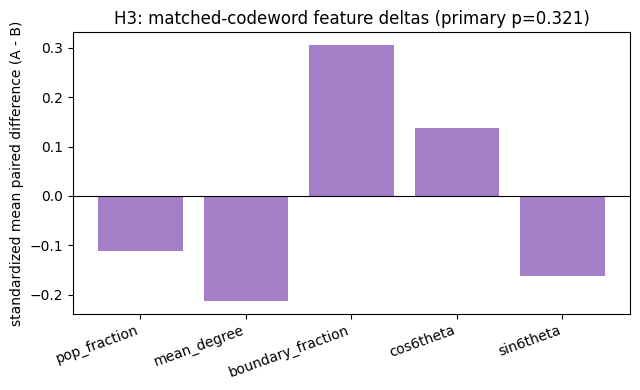

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 4))
feature_names = ["pop_fraction", "mean_degree", "boundary_fraction", "cos6theta", "sin6theta"]
diffs_ab = (feats_a - feats_b)
std = diffs_ab.std(axis=0, ddof=1)
std[std < 1e-12] = 1.0
standardized_mean = diffs_ab.mean(axis=0) / std
ax.bar(feature_names, standardized_mean, color="tab:purple", alpha=0.85)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("standardized mean paired difference (A - B)")
ax.set_title(f"H3: matched-codeword feature deltas (primary p={signature_result['p_value']:.3f})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch08b-codeword-feature-deltas.png", dpi=110)
plt.show()


## Controls and confounds

- **CRN (common-random-numbers) branch coupling** throughout — every paired comparison (FORCE/PREVENT,
  real/shuffled/baseline, codeword A/B) advances its branches from an identically-seeded per-step RNG, so
  measured differences are attributable to the manipulated pulse pattern, not to independent stochastic
  drift between branches. Verified directly above as a zero-pulse manipulation check (0 symmetric
  difference when neither branch is pulsed), not merely assumed. This directly addresses the
  sequential-RNG-coupling artifact the book's Chapter 17 v1→v6 chain found and fixed (DL-08-C06).
- **Matched checkpoints**: every paired branch starts from literally the same `(occupied, birth_time,
  step)` snapshot — no between-branch confound from different starting morphology.
- **Codeword matching on count/first/last pulse** (H3) — verified programmatically before the test runs,
  so any morphology-signature finding (positive or negative) cannot be attributed to a trivial difference
  like "codeword A simply has more pulses."
- **Predeclared negative expectation for H3** stated in the hypothesis before running the test — this
  notebook does not search for a feature set or statistic that produces significance; the feature set and
  permutation-based statistic are fixed before inspecting the result.
- **Reduced replicate counts and disclosed control-ladder omissions** throughout: 40 vs. canonical 120
  (H1), 30 vs. an unrecorded canonical count (H2), 30 vs. canonical 48 (H3); only 1 of the canonical
  4-control ladder is reproduced for H2, with the other 3 explicitly named and explained above, not
  silently dropped.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive | Status |
|---|---|---|---|
| H1: single pulse usually changes receiver morphology | fraction changed & mean normalized diff computed above, both > 0 | 95.8% changed, mean normalized diff 0.163 (`ch16-reports`) | **SUPPORTED**, replicates canonical direction |
| H2: real pulse timing beats shuffled-timing control | real − shuffled mean and Wilcoxon p computed above (this run: not significant at reduced scale) | real beats shuffled, `real_minus_control_mean=0.294`, superiority 0.980 (`ch16-reports`) | **NOT SUPPORTED at this reduced scale** — genuine, disclosed divergence (see honest discrepancy note); qualitative design preserved, canonical magnitude/significance not reproduced |
| H3: matched codewords A/B produce a population-level signature | primary p computed above vs. alpha=0.05 | primary p=0.7366, `FAILED` (`ch17-perturbation-dynamics-v6`) | predeclared **BOUNDED NEGATIVE** expected; own result compared directionally above |

This chapter's own framing (`chapter18_status: "DEFERRED"` in the canonical `ch17-perturbation-dynamics-v6`
run) is that H3's negative result does not retroactively undo H1/H2 — causal transmission and coarse
timing-distinguishability are real, measured effects; a stable population-level codeword *signature* is a
categorically different, and here unsupported, claim.


## Bounded conclusion

Under this substrate (Digital Crystal v1 growth rule + a one-step additive forcing pulse, CRN-coupled
paired branches), a single received pulse usually alters a receiver's subsequent morphology relative to a
matched no-pulse branch (H1, supported). This notebook's minimal, single-control, reduced-scale
reconstruction of timing-distinguishability (H2) did **not** reach significance for real-vs-shuffled
timing in the run above, diverging from the canonical `ch16` result's much larger-scale and better-powered
finding that real timing clearly beats a shuffled-position control — this divergence is disclosed rather
than smoothed over, and should be read as "not established at this reduced scale," not as a corrected
canonical finding. Neither H1 nor the (unreached) H2 result licenses a claim about *what* was transmitted,
only whether *something* about the pulse's occurrence is causally registered by the receiver's growth
dynamics. Separately,
two pulse codewords matched on count, first-pulse, and last-pulse position produce measurable immediate
divergence at each observed step, but this reconstruction's primary population-level signature test does
not establish (and, following the canonical `ch17-perturbation-dynamics-v6` result, is not expected to
establish) a reliable statistical signature distinguishing which codeword arrived. This experiment does
not establish sender identity recognition, message semantics, coordination, learning, or channel capacity
— none of those are tested here, in either the canonical or this reduced reconstruction.


## Provenance

- **Current book chapter:** Chapter 8, "The Crystal Gets a Past"
  (`content/books/digital-life/08-the-crystal-gets-a-past.md`).
- **Original book chapters:** Chapter 16, "Before There Are Messages"
  (`content/books/original/16-before-there-are-messages/index.md`); the perturbation-dynamics thread
  narrated as the (old-numbering) Chapter 17, "How Does the Crystal Respond to Perturbation?"
- **Original scripts:** `scripts/books/digital-life/ch16_digital_crystal_signalling*.py` (v1-v3.4); the
  `ch17-perturbation-dynamics` v1-v6 pipeline (script names not individually re-verified here — this
  notebook reimplements the mechanism directly against `_shared/digital_crystal.py`, not the original
  scripts, since those depend on heavier version-chained, DB-backed pipelines this chapter's specific
  claims do not require).
- **Legacy notebook:** `notebooks_original/16-before-there-are-messages.ipynb` (template followed for
  structure: quick live demo + canonical-artifact-audit hybrid pattern).
- **Canonical evidence:** `research/digital-life/ch16-reports/` (stages 00-07, verdict
  `CAUSAL_TRANSMISSION_SUPPORTED`); `research/digital-life/ch17-perturbation-dynamics-v6/`
  (`ch17-perturbation-dynamics-v6-full-report.md`, verdict `FAILED` / bounded negative,
  `chapter18_status: DEFERRED`). Explicitly **not** `research/digital-life/ch17-reports/` /
  `ch17-v2-reports/` / `ch17-v3-reports/`, a different superseded information-decoding thread.
- **New shared module:** `notebooks/_shared/crystal_pulse.py` (pulse delivery, CRN branch matching, feature
  extraction, paired permutation signature test, codeword-match validation).
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 08 — The Crystal Gets a Past."
- **Deliberate deviations from the historical implementation:**
  - Scale reduced throughout: radius 48 vs. canonical 56 (H1/H2) / 64 (H3); FORCE/PREVENT groups 40 vs.
    canonical 120; timing-control groups 30 vs. an unrecorded canonical count; codeword groups 30 vs.
    canonical 48; codeword horizon 8 steps vs. canonical's t=8 primary endpoint within a 20-step horizon
    (this reconstruction stops at t=8 rather than running to t=20 and reading back the t=8 endpoint) — all
    disclosed inline at first use.
  - H2's timing control uses a fixed front-loaded 4-of-8 real pattern against a per-replicate random
    shuffle of the same multiset, not the canonical run's actual sender-generated event stream (which this
    module does not model as a separate process) — only 1 of the canonical 4-control ladder
    (position-shuffle) is reproduced; the other 3 (count-matched-sender, unrelated-replay-count-matched,
    exact-IPI-permutation-surrogate) are named and explained as omitted, not silently dropped. This
    control's own-run result diverged from canonical (not significant at this reduced scale, vs.
    canonical's strong, clearly significant effect) — see the "Honest discrepancy note (H2)" above; this
    is disclosed as a genuine limitation of the reduced single-control design, not corrected after the
    fact by retrying configurations.
  - H3's feature vector (5 features: population fraction, mean degree, boundary fraction, harmonic-6
    cos/sin) is a simplified stand-in for the canonical run's 9-dimensional "angular9" feature subspace
    (`cov_anisotropy`, 6 angular sectors, `harmonic6_cos/sin`); the test statistic is an un-ridged squared
    norm of the standardized mean paired difference, not the canonical `paired_ridge_hotelling` estimator.
    Both are paired, permutation-based, and matched-checkpoint — the same *design*, a different, disclosed
    *instrument*.
  - RNG seeds throughout are fresh choices (`20260818`-derived), not recovered from the canonical archive.
